<img src="../Images/DSC_Logo.png" style="width: 400px;">

# Basics of Handling Qualitative Data in Python

In this notebook, we move from **preparing text data to analysing it with basic Natural Language Processing (NLP) methods**. Using the interview corpus and the web-scraped texts prepared in the previous notebooks, we will explore different techniques to gain insights from textual data.

First, we analyse the **interview corpus** using sentiment analysis, which allows us to estimate whether a text expresses a more positive or negative tone.

Next, we turn to the **web-scraped Wikipedia texts**. We explore word frequencies, remove common stopwords, and visualize important terms using **WordClouds**. Finally, we introduce **Named Entity Recognition (NER)** with the Python library **SpaCy**. This allows us to automatically identify entities such as places, organizations, or people in the texts. We will also experiment with manually inspecting and improving the detected entities.

# 1. Analysing Interview Data: Sentiment Analysis

One common method in computational text analysis is **sentiment analysis**.  
Sentiment analysis aims to automatically estimate the **emotional tone** of a text. For example, a text can be classified as more **positive**, **negative**, or **neutral**.

This type of analysis can be useful for **exploratory analysis**, but it should be interpreted carefully. Automated models may misinterpret context, irony, or complex statements, especially in qualitative interview data.

For better results, you could use the BERT model (Bidirectional Encoder Representations from Transformers), for example, which allows you to analyse even more complex sentiments. In these notebooks, however, we use a beginner-friendly library.

In [1]:
# Install all required libraries for the notebook
!pip install -q -r ../requirements_A03.txt
print("The libraries pandas 'TextBlob', 'matplotlib', 'Counter', 'stopwords', 'nltk', 'WordCloud' and 'spacy' have been installed.")

The libraries pandas 'TextBlob', 'matplotlib', 'Counter', 'stopwords', 'nltk', 'WordCloud' and 'spacy' have been installed.


### 1.1 Loading the Interview Corpus

In computational text analysis, a collection of texts that we analyze together is often called a **corpus** (plural: corpora).

A corpus can consist of many different types of texts, such as:
- interview transcripts
- newspaper articles
- social media posts
- web pages

In our case, the corpus consists of the **pseudonymized interview transcripts** that we prepared in the previous notebook.

To begin the analysis, we first load all interview files from the folder and combine them into a **pandas DataFrame**. Like we did in A01.

In [3]:
import os
import pandas as pd

# Path to the folder containing the pseudonymized interviews
folder = "../Data/DataA/interviews/pseudonymized"

texts = []
filenames = []

# Loop through all interview files
for file_name in os.listdir(folder):
    
    if file_name.endswith(".txt"):
        
        with open(os.path.join(folder, file_name), "r", encoding="utf-8") as f:
            text = f.read()
        
        texts.append(text)
        filenames.append(file_name)

# Create dataframe
df = pd.DataFrame({
    "filename": filenames,
    "text": texts
})

df.head()

,filename,text
0,interview_01_pseud.txt,Transcription for “interview_01”\n\nSPEAKER_00...
1,interview_02_pseud.txt,Transcription for “interview_02”\n\nSPEAKER_00...
2,interview_03_pseud.txt,Transcription for “interview_03”\n\nSPEAKER_00...
3,interview_04_pseud.txt,Transcription for “interview_04”\n\nSPEAKER_00...


---
### 1.2 Sentiment Analysis with TextBlob
Each row in the dataframe now represents one interview transcript. 

TextBlob is a Python library for Natural Language Processing (NLP) tasks such as sentiment analysis and simple text processing. In our notebooks, we use TextBlob to measure the **sentiment of interview texts**, helping us identify whether passages are expressed in a more positive or negative tone.

> Note: For better results, you could use the BERT model (Bidirectional Encoder Representations), for example, which allows you to analyse even more complex sentiments. In these notebooks, however, we use a beginner-friendly library.

---
Before applying sentiment analysis to our interview data, we first look at a very simple example. This helps us understand how **TextBlob** works and how to interpret its output.

In the following example, we analyze the sentiment of a short sentence. The goal is not yet to study real data, but to see how TextBlob returns information such as **polarity** (how positive or negative a text is) and **subjectivity** (how subjective or objective a text is).

The **polarity score** ranges from -1 to +1:

- **-1** → very negative
- **0** → neutral
- **+1** → very positive

The **subjectivity score** ranges from 0 to 1:

- **0** → very objective
- **1** → very subjective

In [4]:
from textblob import TextBlob

# Example sentence
text = "I really enjoyed learning Python. It was fun and exciting."

blob = TextBlob(text)

print(blob.sentiment)

Sentiment(polarity=0.3666666666666667, subjectivity=0.5666666666666667)


---

Now we apply **TextBlob** to our interview data. Since we loaded the interviews into a **Pandas DataFrame**, we first need to select the text we want to analyze.

To do this, we select the **first interview** in the DataFrame. In Python, indexing starts at **0**, so position `0` refers to the first entry in the dataset.

In [5]:
# Select the first interview from the dataframe
text = df.loc[0, "text"]

blob = TextBlob(text)

print("Polarity:", blob.sentiment.polarity)
print("Subjectivity:", blob.sentiment.subjectivity)
text[:500]

Polarity: 0.15677083333333333
Subjectivity: 0.5951388888888889


'Transcription for “interview_01”\n\nSPEAKER_00: Dana (Interviewer)\nSPEAKER_01: PID001\n\nSPEAKER_00\n[00:00:00] - Thanks for joining me today, PID001 . Could you start by telling me why you decided to learn Python?\n\nSPEAKER_01\n[00:00:04] - Sure! So, I’ve been working on interviews from the “Urban Life Project” in Berlin, and manually coding them takes forever. I thought Python could help automate some tasks, like organizing transcripts or extracting recurring themes.\n\nSPEAKER_00\n[00:00:15] - Mhmm, an'

---
After seeing how the code works for a single interview, we will now apply the complete workflow to the entire dataset. We will use a **loop** to go through all interviews in the DataFrame, perform the **sentiment analysis** for each text, and then add the results to the DataFrame as new columns.

In [6]:
# Import the TextBlob library for sentiment analysis
from textblob import TextBlob

# Create empty lists to store the sentiment results
polarities = []
subjectivities = []

# Loop through all interview texts stored in the dataframe
for text in df["text"]:
    
    # Create a TextBlob object from the interview text
    blob = TextBlob(text)
    
    # Extract the polarity score (-1 = negative, +1 = positive)
    polarities.append(blob.sentiment.polarity)
    
    # Extract the subjectivity score (0 = objective, 1 = subjective)
    subjectivities.append(blob.sentiment.subjectivity)

# Add the sentiment scores as new columns to the dataframe
df["polarity"] = polarities
df["subjectivity"] = subjectivities

# Display the first rows of the updated dataframe
df.head()

,filename,text,polarity,subjectivity
0,interview_01_pseud.txt,Transcription for “interview_01”\n\nSPEAKER_00...,0.156771,0.595139
1,interview_02_pseud.txt,Transcription for “interview_02”\n\nSPEAKER_00...,0.124691,0.480079
2,interview_03_pseud.txt,Transcription for “interview_03”\n\nSPEAKER_00...,0.187681,0.544626
3,interview_04_pseud.txt,Transcription for “interview_04”\n\nSPEAKER_00...,0.129847,0.517149


### 1.3 Visualizing Sentiment Scores

So far, we calculated sentiment scores for each interview and stored them in our dataframe.  
However, tables are not always the easiest way to understand patterns in data.

A common next step in data analysis is **data visualization**. Visualizations help us quickly see patterns, differences, or trends in our data.

In Python, one of the most widely used libraries for creating plots is **Matplotlib**. It allows us to create simple visualizations such as bar charts, line plots, or scatter plots.

In the example below, we create a **bar chart** that shows the sentiment (polarity) score for each interview transcript.

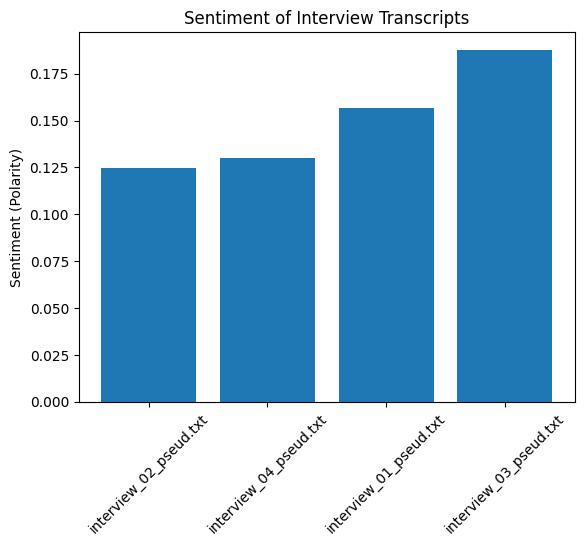

In [7]:
import matplotlib.pyplot as plt

# Sort the dataframe by sentiment so the plot is easier to read
df_sorted = df.sort_values("polarity")

# Create a bar chart
plt.bar(df_sorted["filename"], df_sorted["polarity"])

# Rotate the labels so they don't overlap
plt.xticks(rotation=45)

# Add labels and a title
plt.ylabel("Sentiment (Polarity)")
plt.title("Sentiment of Interview Transcripts")

# Display the plot
plt.show()

## 2. Analysing Web Scraped Data

In the previous section, we analyzed **interview transcripts** using sentiment analysis.  
In this section, we will work with a different type of text data: **web scraped texts from Wikipedia**.

In Notebook A01 and A02, we collected and cleaned several Wikipedia pages about:

- Bremen (state)
- Bremen (city)
- Bremerhaven

Now we can treat these texts as a **small corpus of web documents** and explore their content using simple text analysis techniques.

In the following steps, we will:

1. Load the cleaned Wikipedia texts
2. Explore the most frequent words
3. Visualize word patterns using a **word cloud**
4. Extract **named entities** such as locations or organizations using spaCy

### 2.1 Load the Web Texts

In this step, we load the cleaned Wikipedia texts that we created in the previous notebooks.

All text files in the folder `web-scraping/clean` are read and stored in a **dictionary**.  
This allows us to keep the texts organized and easily access them later for analysis.

A dictionary is useful here because it stores data as **key–value pairs**.  
In our case, the **filename becomes the key** and the **text content becomes the value**.

This means we can easily access a specific text using its filename, for example:

`web_texts["bremen_state.txt"]`

Using a dictionary also makes it easy to **loop through multiple texts** later when we want to create visualizations or extract information from all documents in the corpus.

In [19]:
import os

# Define the path to the folder that contains the cleaned web texts
folder = "../Data/DataA/web-scraping/clean"

# Create an empty dictionary where we will store the texts
# Structure: { "filename.txt": "text content" }
web_texts = {}

# Get a list of all files in the folder
files = os.listdir(folder)

# Loop through each file in the folder
for file_name in files:
    
    # Only process files that end with ".txt"
    if file_name.endswith(".txt"):
        
        # Create the full path to the file
        file_path = os.path.join(folder, file_name)
        
        # Open the file and read its content
        with open(file_path, "r", encoding="utf-8") as f:
            
            # Read the full text and store it in the dictionary
            # The file name becomes the key, the text becomes the value
            web_texts[file_name] = f.read()

# Show which files were loaded
print("Loaded files:")
print(list(web_texts.keys()))

Loaded files:
['bremen_state.txt', 'bremen_city.txt', 'bremerhaven_city.txt']


### 2.2 Exploring Word Frequencies

Now we can start exploring the texts. 

A simple way to explore a text is to look at **word frequencies**: counting how often each word appears. This gives a first impression of potential main topics discussed in the text.

In [20]:
from collections import Counter

# Choose one text from the dictionary to start with
text = web_texts["bremen_state.txt"]

# Split the text into words (already preprocessed in A02)
words = text.split()

# Count word frequencies
word_counts = Counter(words)

# Show the 20 most common words
word_counts.most_common(20)

[('the', 172),
 ('of', 95),
 ('and', 51),
 ('in', 42),
 ('bremen', 32),
 ('to', 27),
 ('a', 23),
 ('is', 20),
 ('as', 20),
 ('state', 18),
 ('by', 16),
 ('city', 14),
 ('bremen,', 12),
 ('on', 12),
 ('was', 11),
 ('an', 10),
 ('at', 9),
 ('german', 9),
 ('for', 9),
 ('its', 8)]

### 2.3 Removing Stopwords

When analyzing word frequencies, common words like "the", "and", or "of" often appear most frequently.  

These words, called **stopwords**, usually do not carry much meaning in terms of topics.  

To get more informative results, we remove the stopwords and count the words again.

In [21]:
from collections import Counter
from nltk.corpus import stopwords

# Load English stopwords (you might need to download them once)
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Create an empty list where we will store the filtered words
filtered_words = []

# Loop through each word in the list 'words'
for word in words:
    
    # Check if the lowercase version of the word is NOT in the stopword list
    if word.lower() not in stop_words:
        
        # If the condition is true, add the word to the new list
        filtered_words.append(word)

# Count the frequencies again
filtered_counts = Counter(filtered_words)

# Show the 20 most common words after removing stopwords
filtered_counts.most_common(20)

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('bremen', 32),
 ('state', 18),
 ('city', 14),
 ('bremen,', 12),
 ('german', 9),
 ('senate', 8),
 ('university', 7),
 ('free', 6),
 ('two', 6),
 ('one', 6),
 ("bremen's", 6),
 ('social', 6),
 ('federal', 6),
 ('port', 5),
 ('lower', 4),
 ('north', 4),
 ('first', 4),
 ('bremerhaven.', 4),
 ("city's", 4),
 ('new', 4)]

---
### 2.4 Visualizing Words with a Wordcloud

A Wordcloud is a simple way to **see which words appear most frequently** in a text.  

The more often a word occurs, the **larger it will appear** in the cloud.  

We will use the `WordCloud` library in Python to create a Wordcloud from the preprocessed text.  
Stopwords have already been removed so that only meaningful words are displayed.

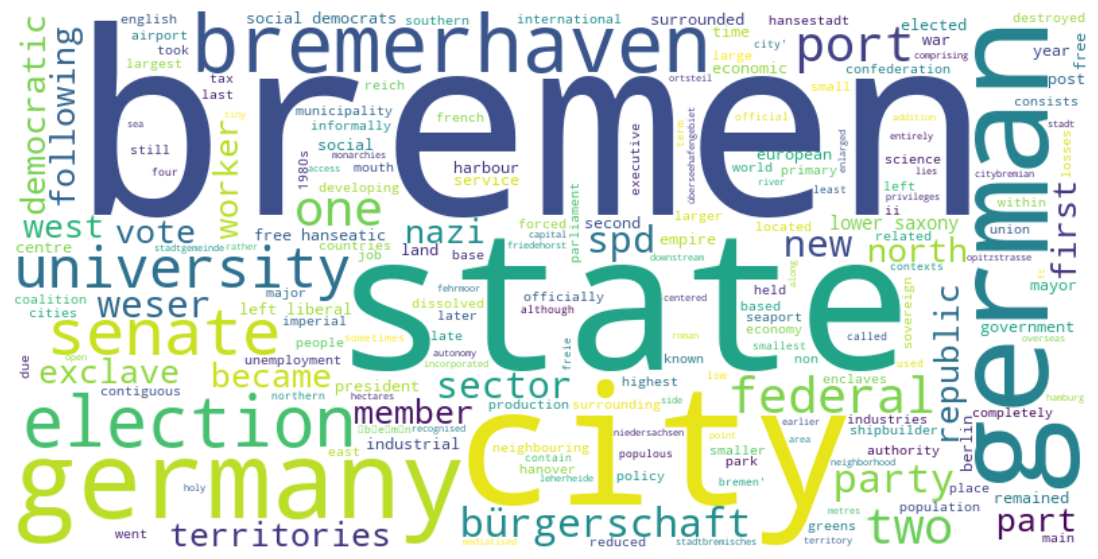

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all words into a single string for WordCloud
text_for_wordcloud = " ".join(filtered_words)

# Create the WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_for_wordcloud)

# Display the WordCloud using matplotlib
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### Exercise 1: Create Wordclouds for All Texts

In this exercise, your task is to **fill in the missing parts of the code** and generate Wordclouds for all web texts.

**Hints:**  
- Find the correct name of the library which needs to be imported.
- Look carefully at the variable names. The missing parts are straightforward but you need to read the code.  
- You do **not** need to change anything else in the code.  
- Stopwords have already been downloaded and the texts are already preprocessed.  

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


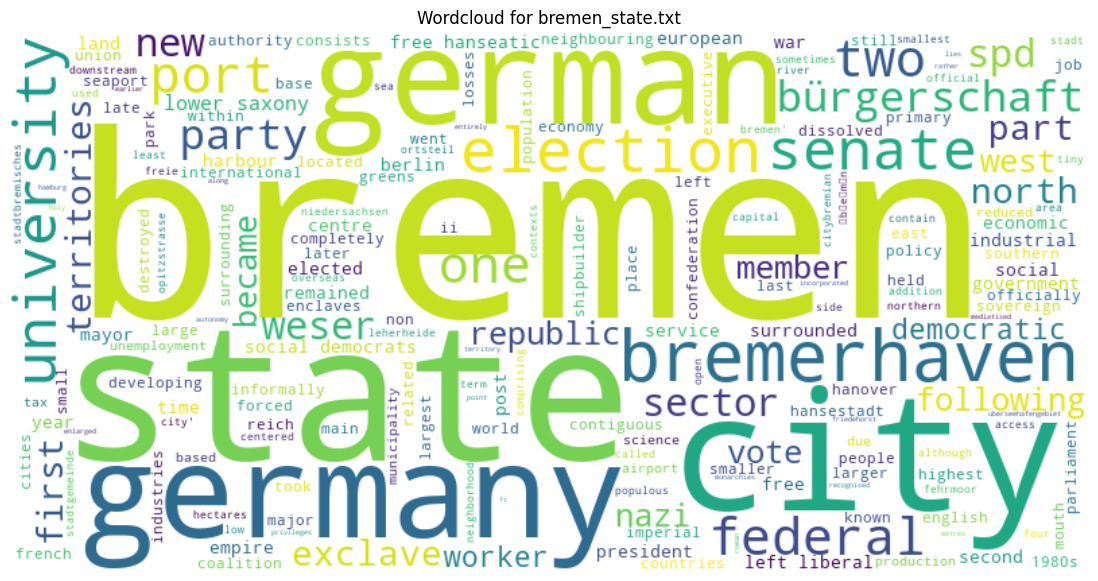

---


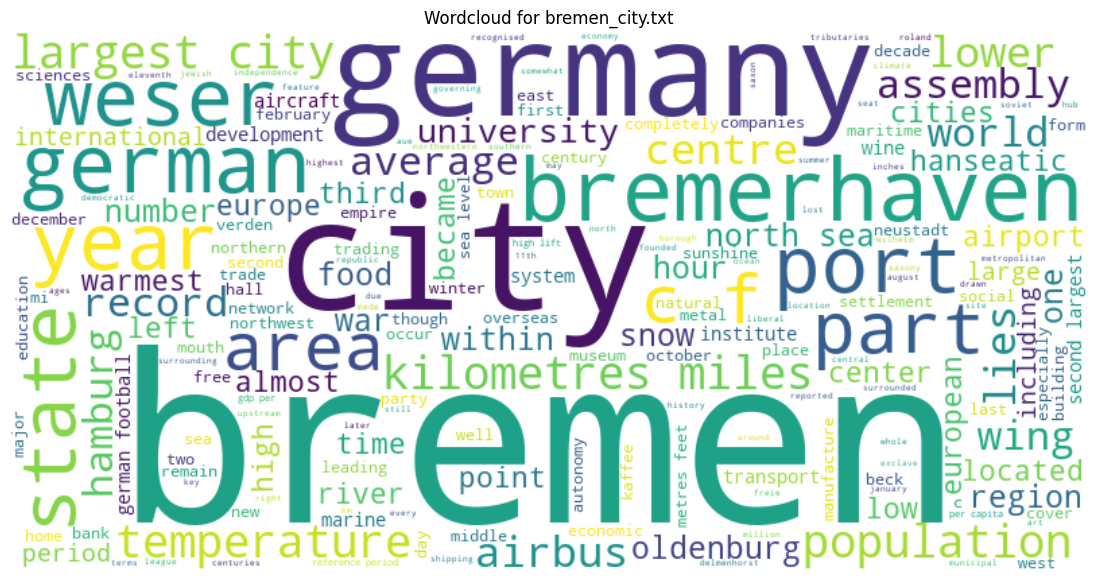

---


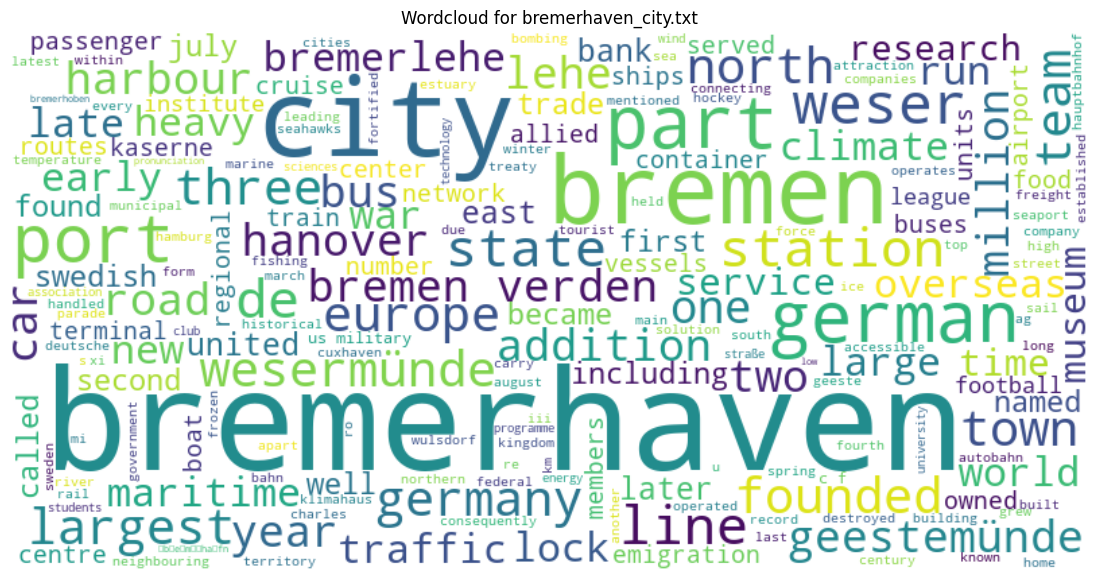

---


In [23]:
from wordcloud import WordCloud     # <-- Fill in here
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

# Download English stopwords (only needed once)
nltk.download('stopwords')
stopwords_set = set(stopwords.words('english'))

# Loop through all texts in the dictionary
for file_name, text in web_texts.items():
    
    # Split the text into individual words (text is already preprocessed)
    words = text.split()
    
    # Remove stopwords (This is the same loop as in the code before, but with list comprehension (advanced Python skills)).
    filtered_words = [word for word in words if word.lower() not in stopwords_set]
    
    # Join the words back into a single string for the WordCloud
    wordcloud_text = " ".join(filtered_words)   # <-- Fill in here: join the filtered words into a single string for the WordCloud
    
    # Create the WordCloud object
    cloud = WordCloud(width=800, height=400, background_color="white").generate(wordcloud_text)
    
    # Display the WordCloud
    plt.figure(figsize=(15, 7))
    plt.imshow(cloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud for {file_name}")
    plt.show()
    print("---")

## 3. Named Entity Recognition with SpaCy

In this section, we will learn how to automatically identify **named entities** in text.  

**Named entities** are proper nouns that refer to things like:  

- **PERSON** – people (e.g., Emily Roberts)  
- **ORG** – organizations (e.g., UNESCO)  
- **GPE** – geopolitical locations, like cities, states, or countries (e.g., Bremen, Germany)  
- **DATE / TIME** – specific dates or times (e.g., 2026, March)  

NER (Named Entity Recognition) is useful in natural language processing because it helps us **quickly find and categorize important elements** in large amounts of text.  

In this notebook, we will:  

1. Load SpaCy and a pre-trained English model.  
2. Apply NER to a single text to see how it works.  
3. Explore NER across multiple texts.  
4. Visualize named entities using simple plots and SpaCy’s built-in visualization tools.  

### 3.1 Load SpaCy and the pre-trained English model

In [13]:
# Install SpaCy model
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 9.7 MB/s  0:00:016m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [14]:
# Import the SpaCy library
import spacy

# Load the small English model
# This model is pre-trained to recognize entities like PERSON, ORG, GPE, DATE, etc.
nlp = spacy.load("en_core_web_sm")

# Check that the model is loaded correctly by printing its pipeline components
print("Pipeline components:", nlp.pipe_names)

Pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


### 3.2 Apply Named Entity Recognition (NER) to a Single Text

In this step, we will apply Named Entity Recognition to a **single text** to see how SpaCy identifies important entities.  

First, however, let's take a look at which entities the model we have loaded can recognize:

In [15]:
# Print all entity labels the model can recognize
print(nlp.get_pipe("ner").labels)

('CARDINAL', 'DATE', 'EVENT', 'FAC', 'GPE', 'LANGUAGE', 'LAW', 'LOC', 'MONEY', 'NORP', 'ORDINAL', 'ORG', 'PERCENT', 'PERSON', 'PRODUCT', 'QUANTITY', 'TIME', 'WORK_OF_ART')


**SpaCy NER Labels (en_core_web_sm) Explained:**

- **CARDINAL** – Numbers without a specific unit (e.g., 1, 42, 1000)  
- **DATE** – Dates (e.g., January 1, 2020; 2021)  
- **EVENT** – Names of events (e.g., Olympic Games, World Cup)  
- **FAC** – Buildings, airports, bridges, etc. (Facilities)  
- **GPE** – Geopolitical entities: countries, cities, states  
- **LANGUAGE** – Languages (e.g., English, German)  
- **LAW** – Laws or legal documents (e.g., GDPR, Constitution)  
- **LOC** – Geographical locations without political affiliation (e.g., mountains, lakes)  
- **MONEY** – Monetary amounts (e.g., $100, 50€)  
- **NORP** – Nationalities, religious or political groups (e.g., German, Catholic)  
- **ORDINAL** – Ordinal numbers (e.g., first, 2nd, third)  
- **ORG** – Organizations (companies, authorities, institutions)  
- **PERCENT** – Percentages (e.g., 50%, 12 percent)  
- **PERSON** – People (names of individuals)  
- **PRODUCT** – Products, goods, vehicles, etc. (e.g., iPhone, Mustang)  
- **QUANTITY** – Quantities (e.g., 10 liters, 3 km)  
- **TIME** – Times (e.g., 12:30, morning)  
- **WORK_OF_ART** – Titles of works of art (books, paintings, movies, etc.)

---
We will use the text from `bremen_state.txt` as an example.  

**What happens in the code:**  

1. We select one text from our `web_texts` dictionary.  
2. We pass the text to the SpaCy model (`nlp(text)`), which processes it and creates a `Doc` object.  
3. We loop through all recognized entities in `doc.ents` and print:  
   - The **entity text** (the actual word or phrase found)  
   - The **entity label** (what type it is, e.g., PERSON, ORG, GPE)  

This way, you can see **which people, organizations, locations, or dates** appear in the text.  

In [24]:
# Select a single text from the web_texts dictionary
text = web_texts["bremen_state.txt"]

# Process the text with SpaCy to create a Doc object
doc = nlp(text)

# Print all entities and their labels
print("Named entities in the text:")
for ent in doc.ents:
    print(ent.text, "-", ent.label_)

Named entities in the text:
german - NORP
german - NORP
german - NORP
free hansestadt - ORG
germany - GPE
16 - CARDINAL
northern germany - GPE
four - CARDINAL
two - CARDINAL
stadt bremerhaven - ORG
the north sea - LOC
two - CARDINAL
first - ORDINAL
second - ORDINAL
only about 4.3 - CARDINAL
two - CARDINAL
two - CARDINAL
überseehafengebiet bremerhaven - PERSON
32.5 metres - QUANTITY
107 ft - QUANTITY
1806 - DATE
1646 - DATE
1186 - DATE
one - CARDINAL
hamburg - GPE
lübeck - PERSON
1873 - DATE
1811 - DATE
berlin - GPE
britain - GPE
first - ORDINAL
french - NORP
congress - ORG
1815 - DATE
johann - PERSON
one - CARDINAL
39 - CARDINAL
german - NORP
1827 - DATE
germany - GPE
germany - GPE
1867 - DATE
the year - DATE
prussia - GPE
austria - GPE
north german - NORP
1871 - DATE
french - NORP
german - NORP
26 - CARDINAL
january 1913 - DATE
berlin - GPE
democrats - NORP
over half - CARDINAL
53.4% - PERCENT
another 41.4% - PERCENT
only 5.1% - PERCENT
seven - CARDINAL
november 1932 - DATE
german - N

### 3.3 Explore Named Entity Recognition across multiple texts

In [25]:
# Create an empty dictionary to store entities for each text
entities_dict = {}

# Loop through all texts in the web_texts dictionary
for file_name, text in web_texts.items():
    
    # Process the text with SpaCy
    doc = nlp(text)
    
    # Extract all entities from the Doc object
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    
    # Store the entities in the dictionary under the file name
    entities_dict[file_name] = entities
    
    # Print the first 10 entities for this text
    print(f"\nFirst 10 named entities in {file_name}:")
    print(entities[:10])


First 10 named entities in bremen_state.txt:
[('german', 'NORP'), ('german', 'NORP'), ('german', 'NORP'), ('free hansestadt', 'ORG'), ('germany', 'GPE'), ('16', 'CARDINAL'), ('northern germany', 'GPE'), ('four', 'CARDINAL'), ('two', 'CARDINAL'), ('stadt bremerhaven', 'ORG')]

First 10 named entities in bremen_city.txt:
[('german', 'NORP'), ('german', 'NORP'), ('two', 'CARDINAL'), ('about 586,000', 'CARDINAL'), ('11th', 'ORDINAL'), ('germany', 'GPE'), ('second', 'ORDINAL'), ('northern germany', 'GPE'), ('germany', 'GPE'), ('60\xa0km', 'QUANTITY')]

First 10 named entities in bremerhaven_city.txt:
[('german', 'NORP'), ('german', 'NORP'), ('the east bank', 'LOC'), ('northern germany', 'GPE'), ('bremerhaven', 'PERSON'), ('1827', 'DATE'), ('one', 'CARDINAL'), ('prussia', 'GPE'), ('1924', 'DATE'), ('1939', 'DATE')]


---
### 3.4 Visualizing GPE Entities with WordCloud

In this step, we will **visualize the GPE (Geopolitical Entity) entities** that we extracted from our texts.  

GPE entities include **cities, countries, and states**, and by creating a WordCloud we can quickly see **which locations are mentioned most frequently** in each text.  

**What the code does:**

1. Loops through all texts in the `entities_dict` that we created in the previous step.  
2. Filters only the entities labeled as `GPE`.  
3. Joins these names into a single string for the WordCloud.  
4. Generates a WordCloud where **more frequently mentioned locations appear larger**.  
5. Displays the WordCloud for each text so you can visually compare the geographic focus of different documents.  

This visualization helps you **spot patterns in location mentions** and also **identify any mistakes or inconsistencies** in the entity recognition (more on this topic after the code block.
).

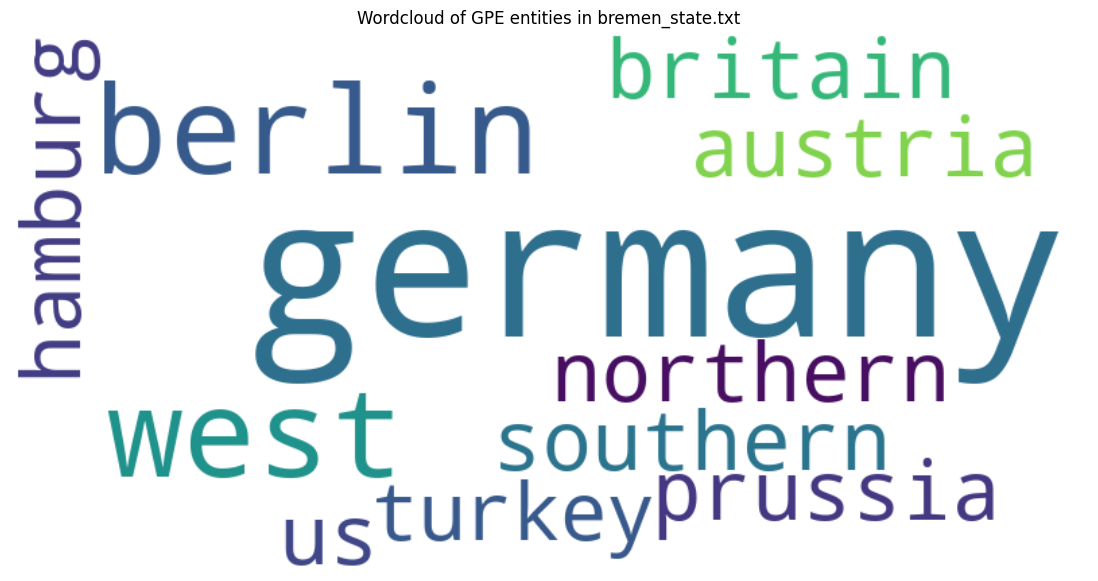

---


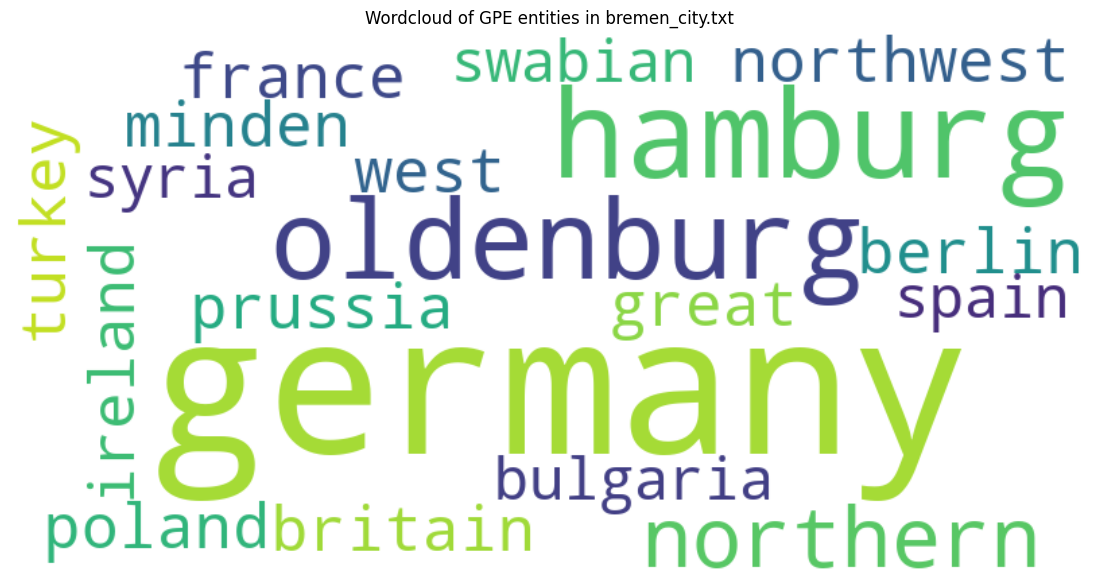

---


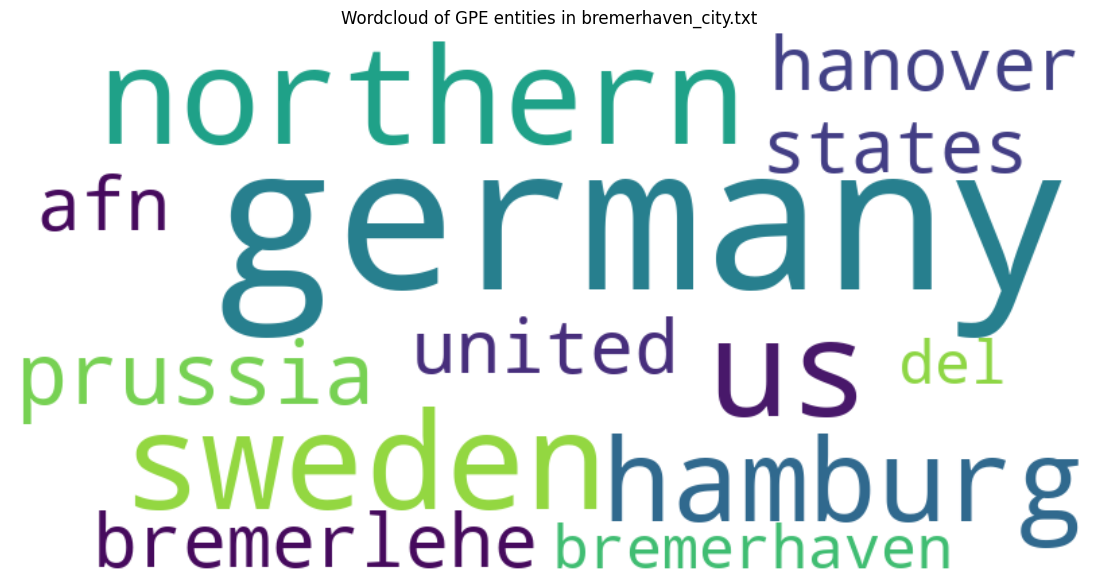

---


In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Loop through all texts in the entities dictionary
for file_name, entities in entities_dict.items():
    
    # Filter only GPE entities (cities, countries, states)
    gpe_entities = [text for text, label in entities if label == "GPE"]
    
    # Count how often each GPE appears
    gpe_counts = Counter(gpe_entities)
    
    # Join the names for the WordCloud
    # WordCloud will make names that appear more often bigger
    gpe_text = " ".join(gpe_entities)
    
    # Create the WordCloud for GPE entities
    cloud = WordCloud(width=800, height=400, background_color="white").generate(gpe_text)
    
    # Display the WordCloud
    plt.figure(figsize=(15, 7))
    plt.imshow(cloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud of GPE entities in {file_name}")
    plt.show()
    print("---")

### Note on model limitations

In our results, you may notice some entities that were misclassified by SpaCy. There are two main reasons for this:  

1. We used a **small English model (`en_core_web_sm`)**, which is convenient for this workshop because it is **quick to install and lightweight**, but it is **not as powerful** as larger models.  
2. We are analyzing **English text that contains German geographical names**, which may not appear in the training data of the English model. This can lead to misclassifications or missed entities.  

A potential solution would be to use a **larger English model (`en_core_web_trf`)**, which usually provides more accurate recognition. However, this model is **difficult to install on the NFDI4Jupyter infrastructure** due to certain system requirements.  

For demonstration purposes in this workshop, the small model is sufficient. If you want to try it yourself, you could run the larger model locally on your computer using an IDE such as **VSCode**.

---
### Exercise 2: Inspect and Improve Named Entities
In this exercise, we will take a closer look at the named entities detected by spaCy and explore how they are stored in a Python dictionary.

The goal is to understand how we can access specific entity categories and, if necessary, manually improve the results. This exercise is different from the others: First, you need to read carefully what happens in the next code blocks. Then there is a task for you to try out for yourself.

---
In the first step, we run the spaCy model on the text and collect all detected entities.

The entities are stored in a **dictionary**, where:
- the **keys** are entity labels (such as `PERSON`, `ORG`, or `GPE`)
- the **values** are lists containing the entities that belong to that category

In [27]:
# Process the text to get entities
doc = nlp(web_texts["bremen_state.txt"])

# Create a dictionary to store entities by label
entities_dict = {}

for ent in doc.ents:
    if ent.label_ not in entities_dict:
        entities_dict[ent.label_] = []
    entities_dict[ent.label_].append(ent.text)

---
We now print all detected entities grouped by their label.

This helps us understand:
- which entity types were detected
- which words appear in each category

In [28]:
# Show all entities
for label, ents in entities_dict.items():
    print(f"{label}: {ents}")  

NORP: ['german', 'german', 'german', 'french', 'german', 'north german', 'french', 'german', 'democrats', 'german', 'democrats', 'nazis', 'german', 'nazi', 'jewish', 'british', 'americans', 'german', 'democrats', 'european', 'west german', 'german', 'german', 'european']
ORG: ['free hansestadt', 'stadt bremerhaven', 'congress', 'kpd', 'senate', 'senate', 'senate', 'the senate (senatspräsident)', 'senate', 'senate', 'senate', 'senate', 'the social democratic party', 'the christian democratic union (cdu)', 'the european union']
GPE: ['germany', 'northern germany', 'hamburg', 'berlin', 'britain', 'germany', 'germany', 'prussia', 'austria', 'berlin', 'us', 'west berlin', 'southern germany', 'germany', 'west germany', 'germany', 'west germany', 'turkey', 'germany', 'germany', 'germany']
CARDINAL: ['16', 'four', 'two', 'two', 'only about 4.3', 'two', 'two', 'one', 'one', '39', '26', 'over half', 'seven', 'only a third', '1,438', '87', 'two', 'one', 'two', '16,000', '16', 'one', '11', 'approx

---
In this step, we focus on the entity category **GPE** (Geopolitical Entities).  
This category includes locations such as **countries, cities, or regions**.

Since all detected entities are stored in the dictionary `entities_dict`, we can access a specific category by using its key. Here, we retrieve the list of all entities that spaCy classified as `GPE` and print them to inspect the results.

In [29]:
# Display all GPE entities from the bremen_state text
gpe_entities = entities_dict["GPE"]  # Get the GPE list from our dictionary
print(gpe_entities)                  # Print the full list

['germany', 'northern germany', 'hamburg', 'berlin', 'britain', 'germany', 'germany', 'prussia', 'austria', 'berlin', 'us', 'west berlin', 'southern germany', 'germany', 'west germany', 'germany', 'west germany', 'turkey', 'germany', 'germany', 'germany']


---
### It's your Turn: Manually correct misclassified entities
Looking at the `GPE` entities, we can see that none of the detected entities are clearly misclassified as geopolitical locations. However, when we inspect other entity categories such as `PERSON`, or `ORG`, we may notice that some entities appearing there could actually refer to places and might therefore belong to the `GPE` category instead.

To investigate this further, we will now take a closer look at other entity categories.

**Task 1:**  
Write a line of Python code that prints **only the entities classified as `PERSON`** from the `entities_dict`.  
This will help you inspect whether any locations were mistakenly classified as people.

In [30]:
person_entities = entities_dict["PERSON"]
print(person_entities)

['überseehafengebiet bremerhaven', 'lübeck', 'johann', 'andreas bovenschulte', 'construction yards', 'bremer vulkan']


When inspecting the `PERSON` entities, we notice that some entities were classified incorrectly.

In the next step, we will focus only on the entities that actually refer to **geographical locations** and should therefore belong to the `GPE` category.

Our goal with the next code block is to **manually correct the dictionary**:  
we will remove incorrectly classified entities from the `PERSON` list (`.remove`) and add them to the `GPE` list instead (`.append`). This helps us improve the quality of our entity data and also demonstrates how dictionaries and lists in Python can be modified.

In [31]:
# Add the misclassified entities to the GPE list
entities_dict["GPE"].append("überseehafengebiet bremerhaven")        # <-- Fill in: Add Entity to GPE
entities_dict["GPE"].append("lübeck")                                # <-- Fill in: Add Entity to GPE

# Remove these entities from the PERSON list
entities_dict["PERSON"].remove("überseehafengebiet bremerhaven")     # <-- Fill in: Remove Entity from PERSON
entities_dict["PERSON"].remove("lübeck")                             # <-- Fill in: Remove Entity from PERSON

# Print the updated categories to check the result
print("Updated PERSON entities:")
print(entities_dict["PERSON"])

print("\nUpdated GPE entities:")
print(entities_dict["GPE"])

Updated PERSON entities:
['johann', 'andreas bovenschulte', 'construction yards', 'bremer vulkan']

Updated GPE entities:
['germany', 'northern germany', 'hamburg', 'berlin', 'britain', 'germany', 'germany', 'prussia', 'austria', 'berlin', 'us', 'west berlin', 'southern germany', 'germany', 'west germany', 'germany', 'west germany', 'turkey', 'germany', 'germany', 'germany', 'überseehafengebiet bremerhaven', 'lübeck']


---
### Exercise 3 (advanced): Improving and Extending the Entity Analysis

In this task, you will continue working with the named entities and explore ways to improve and reuse your analysis. The goal is to practice working with **dictionaries, lists, and basic Python operations**, while also thinking about how to structure code more efficiently.

You can work through the following steps:

**1. Correct additional entity classifications in bremen_state.txt**  
Using the same approach as in the previous code block, inspect other entity categories (for example `NORP`, `ORG`, or `PERSON`).  
If you find entities that actually refer to **geographical locations**, manually move them from their current category to the `GPE` category by:
- adding them to `entities_dict["GPE"]`
- removing them from their original category.

**2. Create a WordCloud of the GPE entities**  
Once you are satisfied with your corrected `GPE` list, visualize the locations by creating a **WordCloud**.  
You can reuse the WordCloud code from earlier in the notebook. Simply copy the code and adapt it so that it uses the `GPE` entities you extracted from the dictionary.

**3. Repeat the analysis for other texts**  
Apply the same steps to the other Wikipedia texts:
- `bremen_city.txt`
- `bremerhaven_city.txt`

This will help you see whether the model behaves differently across different texts.

**Optional challenge (advanced):**  
If you already have more experience with Python, think about how you could **automate these steps using loops**. For example, you could write a loop that:
- processes multiple files,
- extracts entities,
- applies manual corrections,
- and generates WordClouds automatically.

This is more advanced and not required for completing the exercise, but it is a good challenge if you want to practice writing more efficient Python code.